# Empty- vs Cell-Driven Lattice Growth

## Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from core import (
    SquareLattice,
    DiskSeed,
    CellDrivenGrowth,
    EmptyDrivenGrowth,
    CultureSimulator,
)
from lib import (
    plot_population_curves,
    plot_snapshots,
    plot_birth_time,
    plot_cell_id,
    summarize_simulation,
)

## Same $\tau$

In [2]:
tau = 1.0
t_final = 100.0
seed = 12345

# The lattice must be large enough so that the colony does not fill it too early.
lattice = SquareLattice(nrows=101, ncols=101, periodic=False)

initializer = DiskSeed(radius=5)
initial_state = initializer.generate(lattice)

simulator = CultureSimulator(lattice)

model_1 = CellDrivenGrowth(tau=tau)
model_2 = EmptyDrivenGrowth(tau=tau)

snapshot_times = [0.0, 10.0, 25.0, 50.0, 100.0]

rng1 = np.random.default_rng(seed)
rng2 = np.random.default_rng(seed + 1)

In [3]:
result_1 = simulator.run(
    initial_state=initial_state,
    model=model_1,
    t_final=t_final,
    rng=rng1,
    snapshot_times=snapshot_times,
)

result_2 = simulator.run(
    initial_state=initial_state,
    model=model_2,
    t_final=t_final,
    rng=rng2,
    snapshot_times=snapshot_times,
)

In [4]:
summarize_simulation(result_1, "cell_driven")
print()
summarize_simulation(result_2, "empty_driven")

Model: cell_driven
Final time: 56.980250
Initial cells: 81
Final cells: 10201
Number of events: 10120

Model: empty_driven
Final time: 31.683907
Initial cells: 81
Final cells: 10201
Number of events: 10120


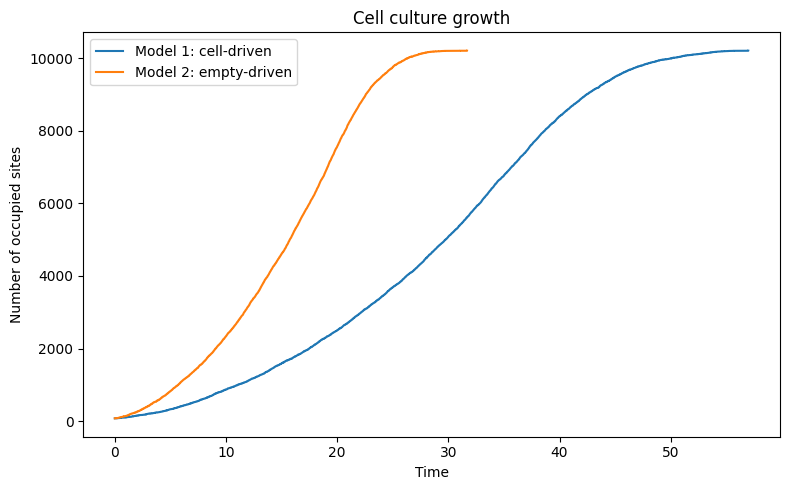

In [5]:
plot_population_curves(
    results=[result_1, result_2],
    labels=["Model 1: cell-driven", "Model 2: empty-driven"],
)

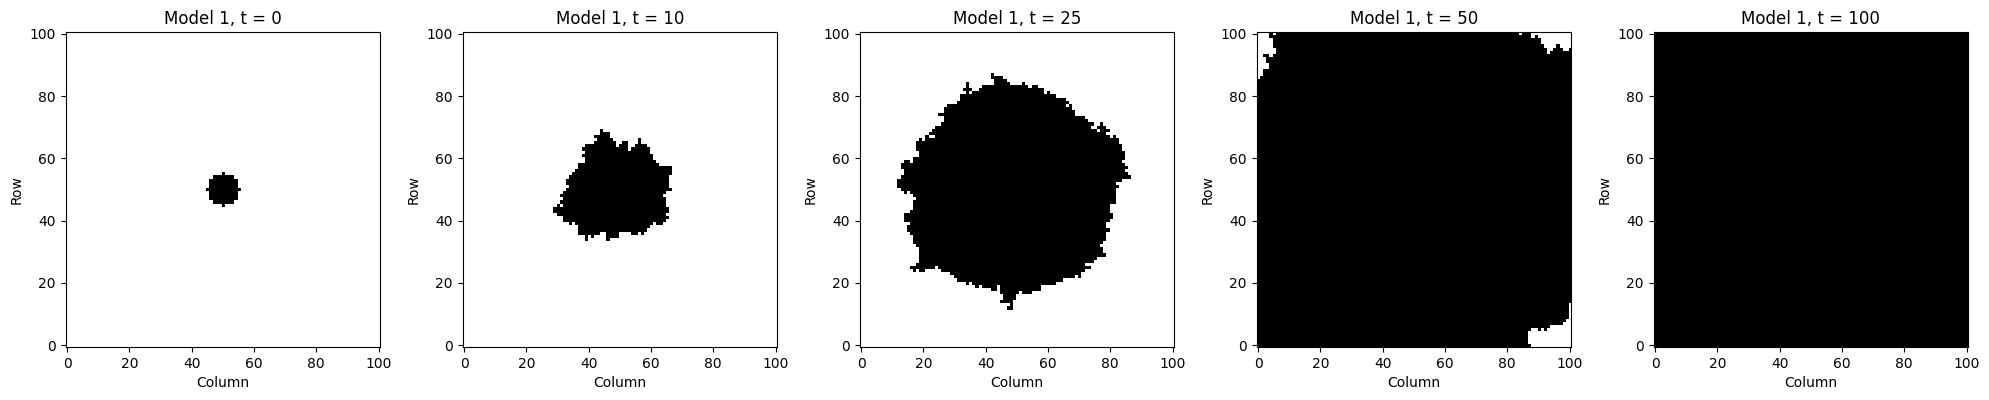

In [6]:
plot_snapshots(
    lattice=lattice,
    result=result_1,
    times_to_show=snapshot_times,
    title_prefix="Model 1, ",
)

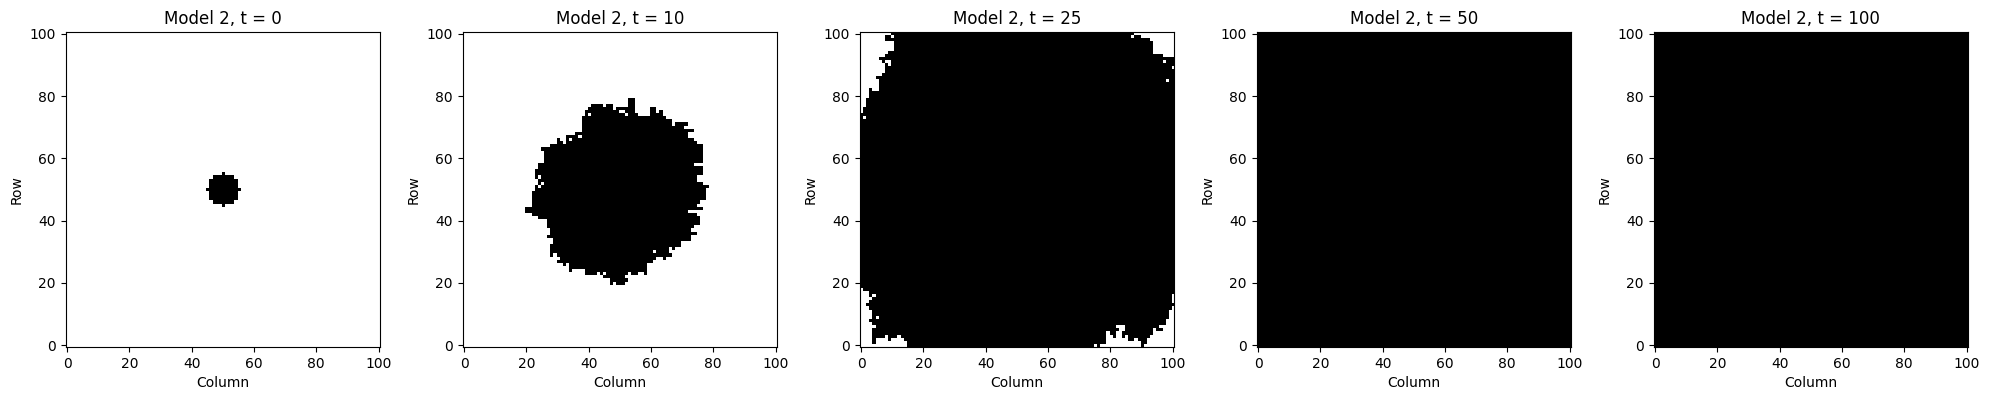

In [7]:
plot_snapshots(
    lattice=lattice,
    result=result_2,
    times_to_show=snapshot_times,
    title_prefix="Model 2, ",
)

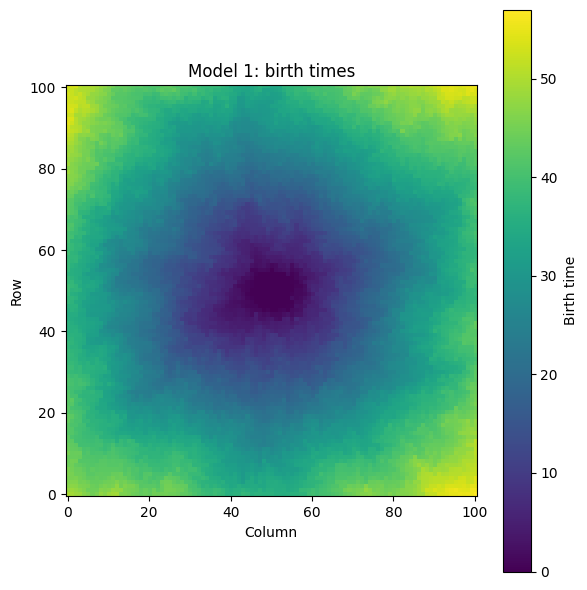

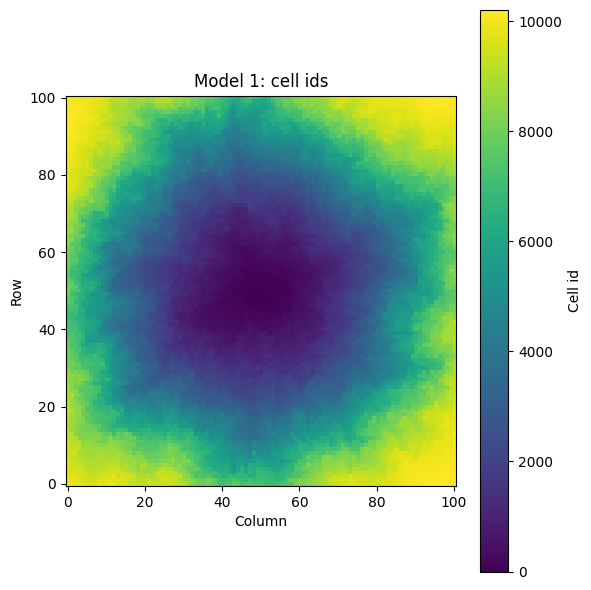

In [8]:
plot_birth_time(
    lattice=lattice,
    state=result_1.final_state,
    title="Model 1: birth times",
)

plot_cell_id(
    lattice=lattice,
    state=result_1.final_state,
    title="Model 1: cell ids",
)

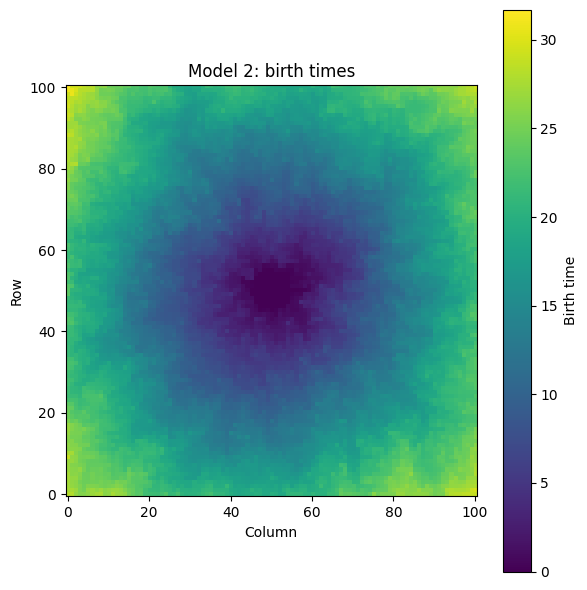

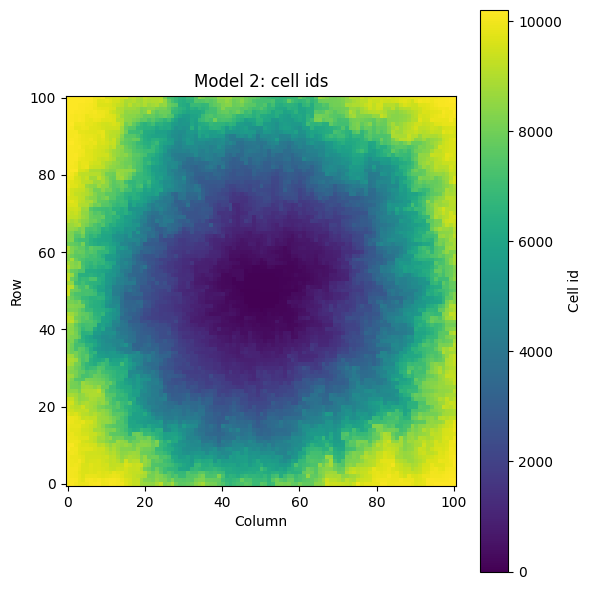

In [9]:
plot_birth_time(
    lattice=lattice,
    state=result_2.final_state,
    title="Model 2: birth times",
)

plot_cell_id(
    lattice=lattice,
    state=result_2.final_state,
    title="Model 2: cell ids",
)

## Empty-driven model with $\tau_{empty}=\tau_{cell}/2$

In [3]:
tau = 1.0
t_final = 100.0
seed = 12345

# The lattice must be large enough so that the colony does not fill it too early.
lattice = SquareLattice(nrows=101, ncols=101, periodic=False)

initializer = DiskSeed(radius=5)
initial_state = initializer.generate(lattice)

simulator = CultureSimulator(lattice)

model_1 = CellDrivenGrowth(tau=tau)
model_2 = EmptyDrivenGrowth(tau=tau*2.0)  # In a square lattice, each cell has 4 neighbors,
# so the empty-driven model should grow about 2 times faster than the cell-driven model 
# (2 being an average of 2 empty neighbors per cell).

snapshot_times = [0.0, 10.0, 25.0, 50.0, 100.0]

rng1 = np.random.default_rng(seed)
rng2 = np.random.default_rng(seed + 1)

In [4]:
result_1 = simulator.run(
    initial_state=initial_state,
    model=model_1,
    t_final=t_final,
    rng=rng1,
    snapshot_times=snapshot_times,
)

result_2 = simulator.run(
    initial_state=initial_state,
    model=model_2,
    t_final=t_final,
    rng=rng2,
    snapshot_times=snapshot_times,
)

In [5]:
summarize_simulation(result_1, "cell_driven")
print()
summarize_simulation(result_2, "empty_driven")

Model: cell_driven
Final time: 56.980250
Initial cells: 81
Final cells: 10201
Number of events: 10120

Model: empty_driven
Final time: 63.367814
Initial cells: 81
Final cells: 10201
Number of events: 10120


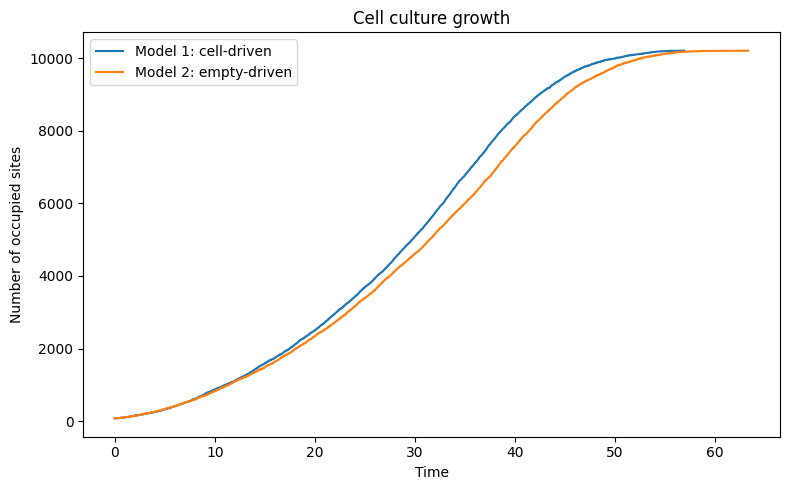

In [6]:
plot_population_curves(
    results=[result_1, result_2],
    labels=["Model 1: cell-driven", "Model 2: empty-driven"],
)

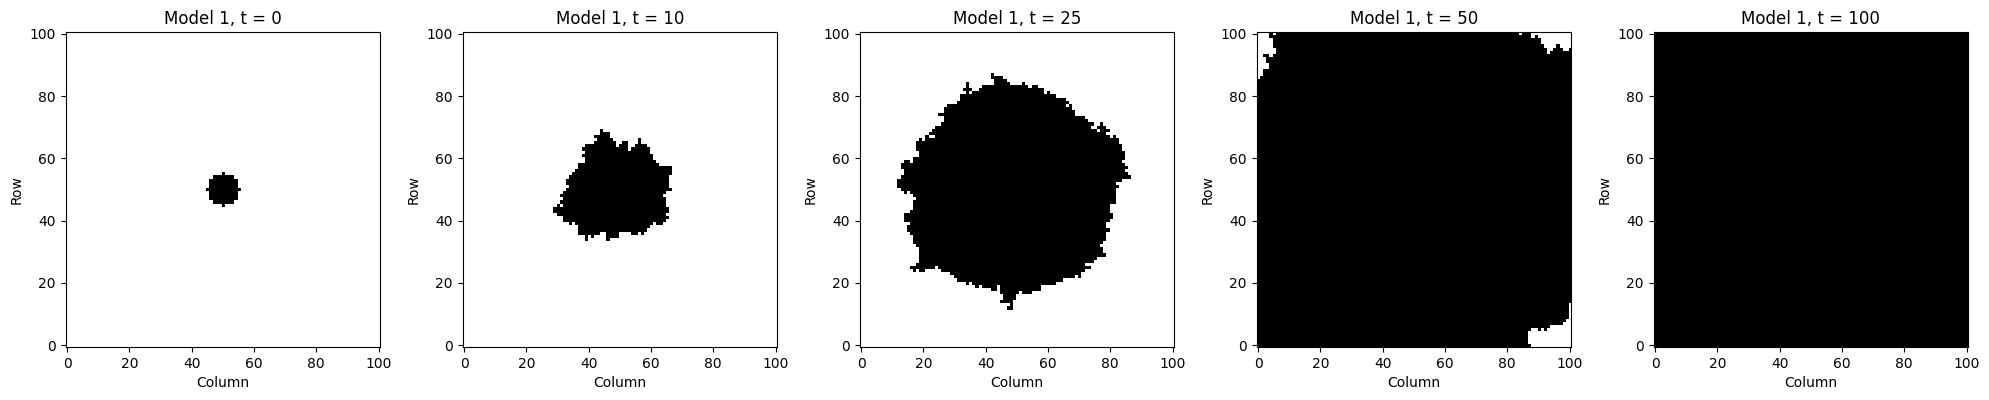

In [7]:
plot_snapshots(
    lattice=lattice,
    result=result_1,
    times_to_show=snapshot_times,
    title_prefix="Model 1, ",
)

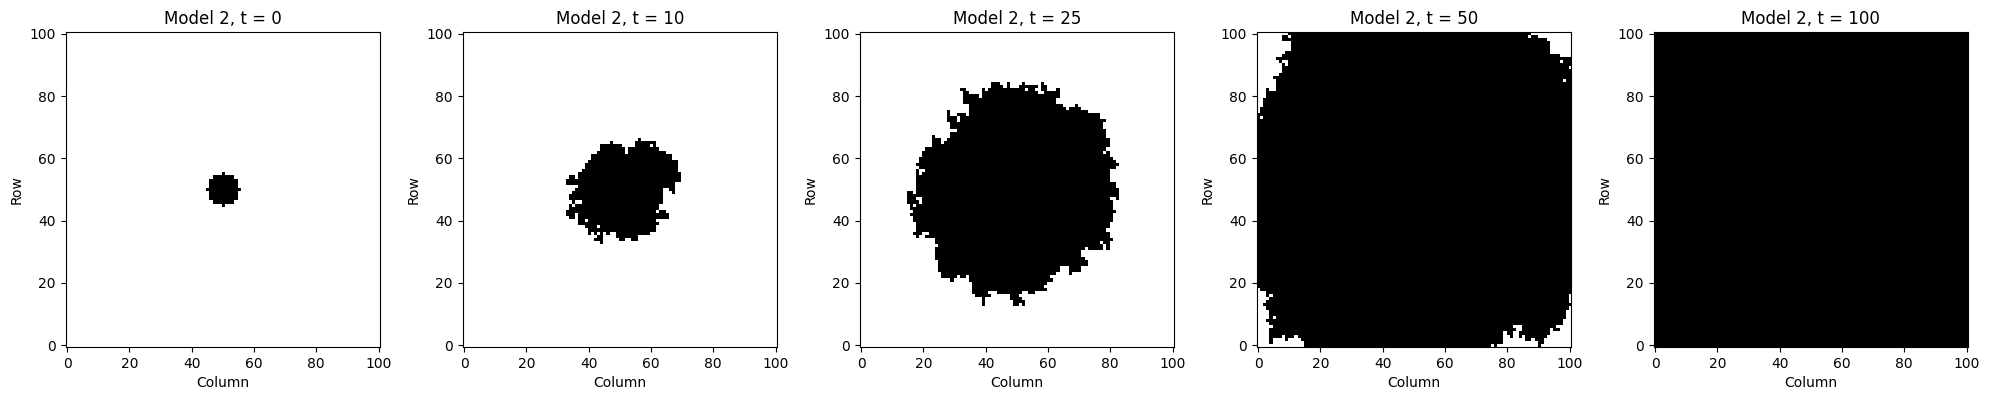

In [8]:
plot_snapshots(
    lattice=lattice,
    result=result_2,
    times_to_show=snapshot_times,
    title_prefix="Model 2, ",
)

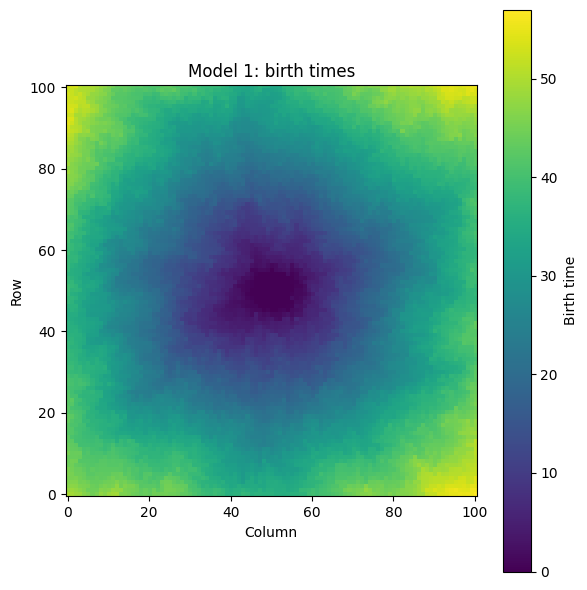

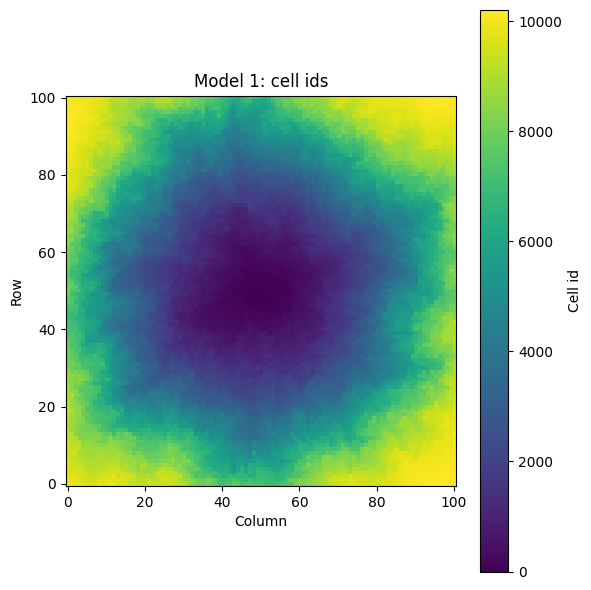

In [9]:
plot_birth_time(
    lattice=lattice,
    state=result_1.final_state,
    title="Model 1: birth times",
)

plot_cell_id(
    lattice=lattice,
    state=result_1.final_state,
    title="Model 1: cell ids",
)

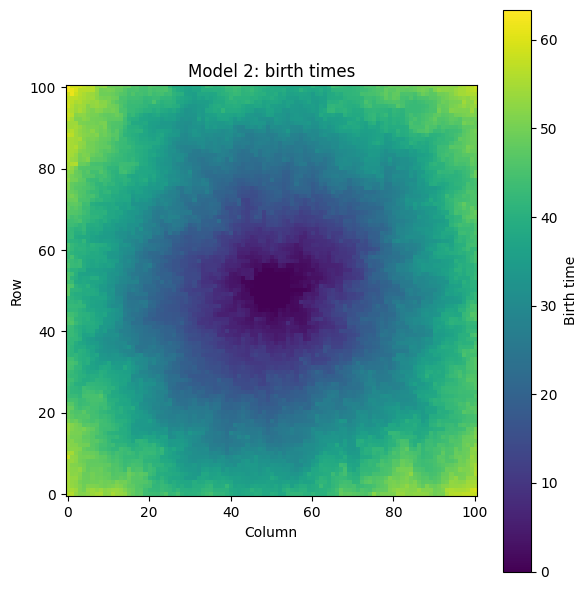

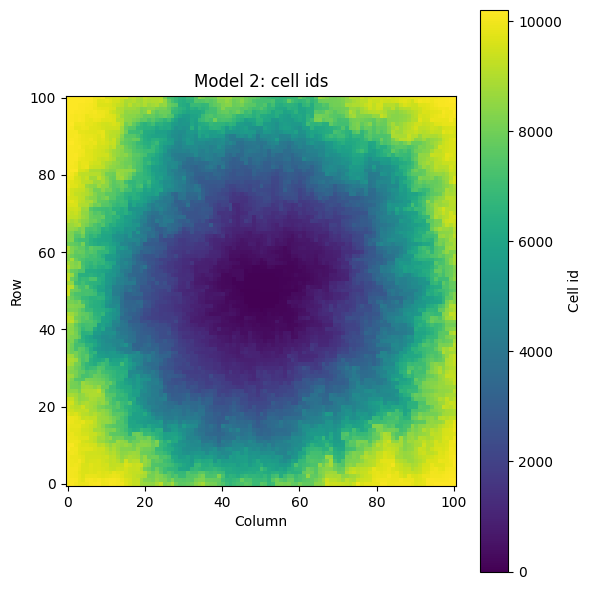

In [10]:
plot_birth_time(
    lattice=lattice,
    state=result_2.final_state,
    title="Model 2: birth times",
)

plot_cell_id(
    lattice=lattice,
    state=result_2.final_state,
    title="Model 2: cell ids",
)